# E-Commerce Review Sentiment Analysis
**Author:** Raja Rashid  
**Project:** M.Sc. Final Year Project (2024–2025)  
**Goal:** Classify customer product reviews as Positive, Neutral, or Negative using NLP and Machine Learning.

---
## Pipeline Overview
1. Load & Explore Data
2. Text Preprocessing
3. Feature Extraction (TF-IDF)
4. Handle Class Imbalance (SMOTE)
5. Train Models (SVM & Naive Bayes)
6. Evaluate & Compare Models
7. Save Models

## 1. Import Libraries

In [17]:
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import re
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Class imbalance
from imblearn.over_sampling import SMOTE

# Model training
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Model saving
import joblib

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print('All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. Load & Explore Data

In [43]:
# Load dataset
df = pd.read_csv('byakh.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nMissing Values:\n{df.isnull().sum()}')
df.head()

Dataset Shape: (5568, 5)

Columns: ['product_title', 'rating', 'summary', 'review', 'sentiment']

Missing Values:
product_title    0
rating           0
summary          0
review           0
sentiment        0
dtype: int64


,product_title,rating,summary,review,sentiment
0,OnePlus Bullets Wireless Z Bluetooth Headset,5,Wonderful,THIS IS THE BEST AND BEST PRODUCT I'VE EVER US...,Positive
1,BoAt BassHeads 100 Wired Headset,4,Wonderful,looks wise it's so good. works properly defin...,Positive
2,BoAt BassHeads 100 Wired Headset,4,Good at this price,It has better grip than others in the ears. On...,Positive
3,OnePlus Bullets Wireless Z Bass Edition Blueto...,4,Good choice,"""Super delivery within one day. Thaks for the ...",Positive
4,BoAt BassHeads 100 Wired Headset,4,Wonderful,"""build quality is good and sound is also good ...",Positive


sentiment Distribution:
sentiment
Positive    3548
Negative    1398
Neutral      622
Name: count, dtype: int64


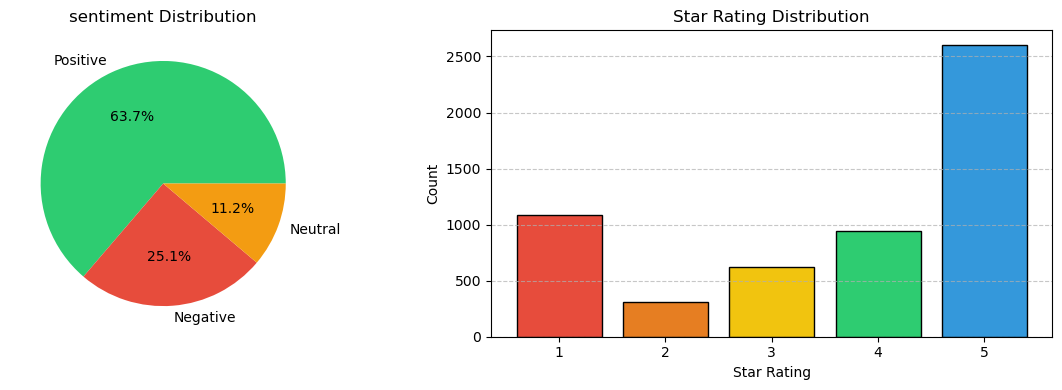

In [20]:
# Sentiment distribution
print('sentiment Distribution:')
print(df['sentiment'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
sentiment_counts = df['sentiment'].value_counts()
axes[0].pie(sentiment_counts, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('sentiment Distribution')

# Star rating distribution
rating_counts = df['rating'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
axes[1].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black')
axes[1].set_title('Star Rating Distribution')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Text Preprocessing

In [30]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [31]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [32]:
from tqdm import tqdm

tqdm.pandas()

df['cleaned_review'] = df['review'].progress_apply(preprocess_text)
df['cleaned_summary'] = df['summary'].progress_apply(preprocess_text)

100%|██████████| 5568/5568 [00:00<00:00, 26944.45it/s]


In [33]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full text cleaning pipeline:
    - Remove emojis, URLs, special characters
    - Lowercase, tokenize, remove stopwords, lemmatize
    """
    # Remove emojis
    text = emoji.replace_emoji(str(text), replace='')
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+|ftp://\S+', '', text)
    # Remove special characters (keep letters and numbers)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Lowercase and strip whitespace
    text = text.lower().strip()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing with progress bar
tqdm.pandas(desc='Preprocessing reviews')
df['cleaned_review'] = df['review'].progress_apply(preprocess_text)
df['cleaned_summary'] = df['summary'].progress_apply(preprocess_text)

# Combine summary and review for richer features
df['combined_text'] = df['cleaned_summary'] + ' ' + df['cleaned_review']

print('✅ Text preprocessing complete!')
print('\nSample cleaned review:')
print('Original:', df['review'].iloc[0])
print('Cleaned: ', df['combined_text'].iloc[0])

Preprocessing reviews: 100%|██████████| 5568/5568 [00:00<00:00, 7225.53it/s]

✅ Text preprocessing complete!

Sample cleaned review:
Original: THIS IS THE BEST AND BEST PRODUCT I'VE EVER USE.... AFTER USES 4 WIRELESS HEADPHONE I CHOOSE THIS ONE. I AM SATISFIED. I LOVE THIS REALLY.ÃƒÂ¢Ã‚ÂÃ‚Â¤ÃƒÂ¯Ã‚Â¸Ã‚ÂÃƒÂ¢Ã‚ÂÃ‚Â¤ÃƒÂ¯Ã‚Â¸Ã‚ÂÃƒÂ¢Ã‚ÂÃ‚Â¤ÃƒÂ¯Ã‚Â¸Ã‚Â I WANT YO SAY ALL PEOPLE THIS IS EPIC PRODUCT. REALLY NICE.
Cleaned:  wonderful best best product ive ever use us 4 wireless headphone choose one satisfied love really want yo say people epic product really nice


In [38]:
df.head()

,product_title,rating,summary,review,sentiment,cleaned_review,cleaned_summary,combined_text
0,OnePlus Bullets Wireless Z Bluetooth Headset,5,Wonderful,THIS IS THE BEST AND BEST PRODUCT I'VE EVER US...,Positive,best best product ive ever use us 4 wireless h...,wonderful,wonderful best best product ive ever use us 4 ...
1,BoAt BassHeads 100 Wired Headset,4,Wonderful,looks wise it's so good. works properly defin...,Positive,look wise good work properly definitely recomm...,wonderful,wonderful look wise good work properly definit...
2,BoAt BassHeads 100 Wired Headset,4,Good at this price,It has better grip than others in the ears. On...,Positive,better grip others ear one thing noticed feel ...,good price,good price better grip others ear one thing no...
3,OnePlus Bullets Wireless Z Bass Edition Blueto...,4,Good choice,"""Super delivery within one day. Thaks for the ...",Positive,super delivery within one day thaks filpkart d...,good choice,good choice super delivery within one day thak...
4,BoAt BassHeads 100 Wired Headset,4,Wonderful,"""build quality is good and sound is also good ...",Positive,build quality good sound also good per rate,wonderful,wonderful build quality good sound also good p...


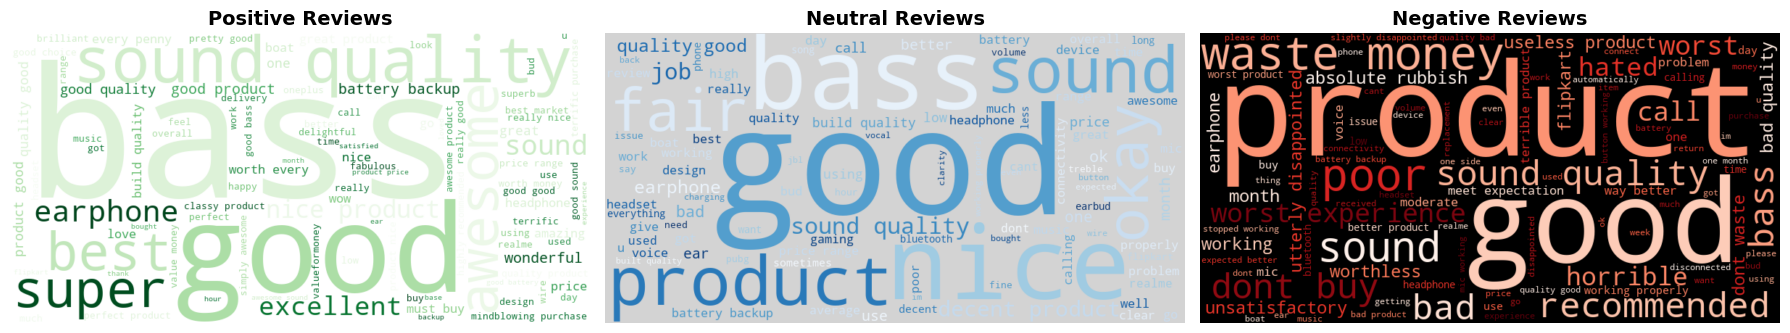

In [37]:
# Word clouds per sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = ['Positive', 'Neutral', 'Negative']
colors_bg = ['white', 'lightgray', 'black']
colormaps = ['Greens', 'Blues', 'Reds']

for ax, sentiment, bg, cmap in zip(axes, sentiments, colors_bg, colormaps):
    text = ' '.join(df[df['sentiment'] == sentiment]['combined_text'])
    wc = WordCloud(width=800, height=400, background_color=bg,
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Reviews', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Feature Extraction & Train-Test Split

In [39]:
# Encode sentiment labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])

label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))
print('Label Mapping:', label_mapping)

# TF-IDF Vectorization (unigrams + bigrams)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X = vectorizer.fit_transform(df['combined_text']).toarray()

print(f'\nFeature Matrix Shape: {X.shape}')
print(f'Labels Shape: {y.shape}')

# Train-test split (80/20, stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Label Mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}

Feature Matrix Shape: (5568, 5000)
Labels Shape: (5568,)

Training samples: 4454
Testing samples:  1114


In [40]:
print('Class distribution before SMOTE:')
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(label_encoder.classes_, counts):
    print(f'  {label}: {count}')

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print('\nClass distribution after SMOTE:')
unique, counts = np.unique(y_train_balanced, return_counts=True)
for label, count in zip(label_encoder.classes_, counts):
    print(f'  {label}: {count}')

Class distribution before SMOTE:
  Negative: 1118
  Neutral: 498
  Positive: 2838

Class distribution after SMOTE:
  Negative: 2838
  Neutral: 2838
  Positive: 2838


## 6. Train Models

In [41]:
# --- Support Vector Machine ---
print('Training SVM...')
svm_model = SVC(C=1, kernel='linear', gamma='scale', random_state=42)
svm_model.fit(X_train_balanced, y_train_balanced)

y_pred_svm = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f'\nSVM Accuracy: {svm_accuracy:.4f}')
print('\nSVM Classification Report:')
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))

Training SVM...

SVM Accuracy: 0.9641

SVM Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.96      0.97       280
     Neutral       0.89      0.90      0.89       124
    Positive       0.97      0.98      0.97       710

    accuracy                           0.96      1114
   macro avg       0.95      0.94      0.95      1114
weighted avg       0.96      0.96      0.96      1114



In [42]:
# --- Naive Bayes ---
print('Training Naive Bayes...')
nb_model = MultinomialNB(alpha=1)
nb_model.fit(X_train_balanced, y_train_balanced)

y_pred_nb = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f'\nNaive Bayes Accuracy: {nb_accuracy:.4f}')
print('\nNaive Bayes Classification Report:')
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))

Training Naive Bayes...

Naive Bayes Accuracy: 0.9273

Naive Bayes Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.91      0.93       280
     Neutral       0.71      0.81      0.76       124
    Positive       0.96      0.95      0.96       710

    accuracy                           0.93      1114
   macro avg       0.87      0.89      0.88      1114
weighted avg       0.93      0.93      0.93      1114



In [ ]:
## 7. Evaluate & Compare Models

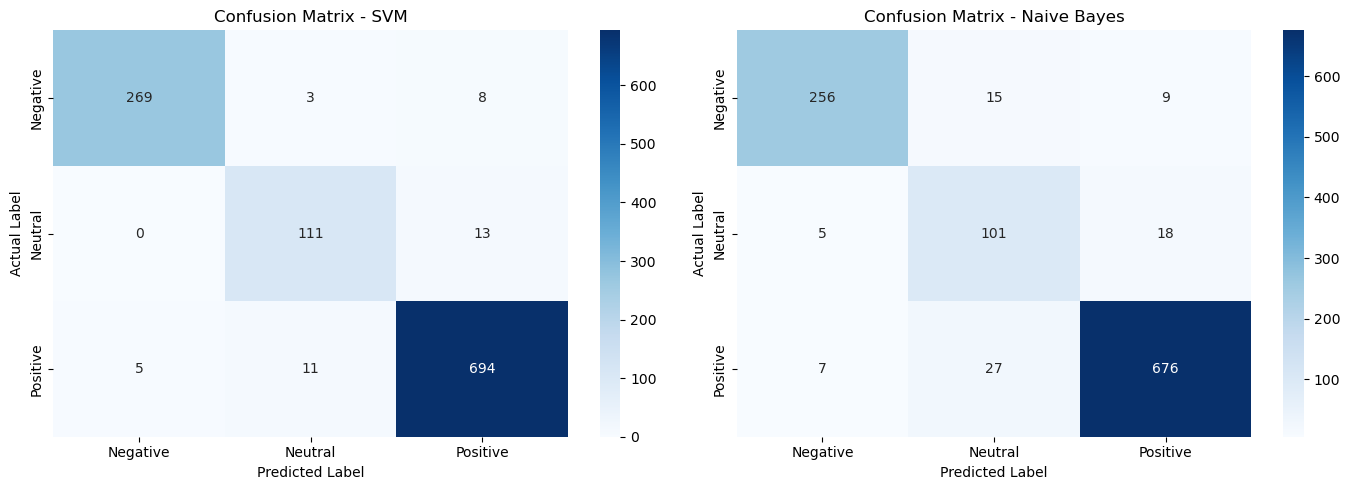

In [44]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_svm, y_pred_nb],
    ['SVM', 'Naive Bayes']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')
    ax.set_title(f'Confusion Matrix - {title}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

Running 5-fold cross-validation...

Naive Bayes CV Accuracy: 0.8878 ± 0.0044
SVM CV Accuracy:         0.9605 ± 0.0023


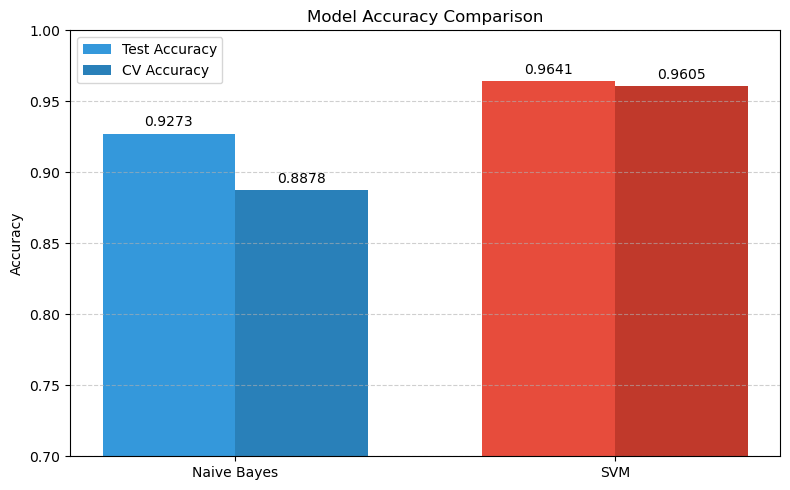

In [45]:
# Cross-validation comparison
print('Running 5-fold cross-validation...')

nb_cv_scores = cross_val_score(MultinomialNB(alpha=1), X, y, cv=5, scoring='accuracy')
svm_cv_scores = cross_val_score(SVC(C=1, kernel='linear', gamma='scale'), X, y, cv=5, scoring='accuracy')

print(f'\nNaive Bayes CV Accuracy: {np.mean(nb_cv_scores):.4f} ± {np.std(nb_cv_scores):.4f}')
print(f'SVM CV Accuracy:         {np.mean(svm_cv_scores):.4f} ± {np.std(svm_cv_scores):.4f}')

# Model comparison bar chart
models = ['Naive Bayes', 'SVM']
test_accuracies = [nb_accuracy, svm_accuracy]
cv_accuracies = [np.mean(nb_cv_scores), np.mean(svm_cv_scores)]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, test_accuracies, width, label='Test Accuracy', color=['#3498db', '#e74c3c'])
bars2 = ax.bar(x + width/2, cv_accuracies, width, label='CV Accuracy', color=['#2980b9', '#c0392b'])

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', fontsize=10)

ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Save Models

In [46]:
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(nb_model, 'naive_bayes_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print('✅ Models saved successfully!')
print('  - svm_model.pkl')
print('  - naive_bayes_model.pkl')
print('  - tfidf_vectorizer.pkl')
print('  - label_encoder.pkl')

✅ Models saved successfully!
  - svm_model.pkl
  - naive_bayes_model.pkl
  - tfidf_vectorizer.pkl
  - label_encoder.pkl


## 9. Predict on New Review

In [48]:
def predict_sentiment(review_text, model=nb_model):
    """Predict sentiment for a new review string."""
    cleaned = preprocess_text(review_text)
    vectorized = vectorizer.transform([cleaned]).toarray()
    prediction = model.predict(vectorized)
    return label_encoder.inverse_transform(prediction)[0]

# Example predictions
examples = [
    'This product is absolutely amazing! Best purchase ever.',
    'Terrible quality, broke after one day. Very disappointed.',
    'It is okay, nothing special but does the job.',
    "This product is amazing. Great quality and fast delivery.",
    "The product is okay. Nothing special, average performance.",
    "Very disappointed. Waste of money and poor quality."

]

print('Sample Predictions:')
print('-' * 60)
for review in examples:
    sentiment = predict_sentiment(review)
    print(f'Review:    {review[:50]}...')
    print(f'Sentiment: {sentiment}')
    print()

Sample Predictions:
------------------------------------------------------------
Review:    This product is absolutely amazing! Best purchase ...
Sentiment: Positive

Review:    Terrible quality, broke after one day. Very disapp...
Sentiment: Negative

Review:    It is okay, nothing special but does the job....
Sentiment: Neutral

Review:    This product is amazing. Great quality and fast de...
Sentiment: Positive

Review:    The product is okay. Nothing special, average perf...
Sentiment: Neutral

Review:    Very disappointed. Waste of money and poor quality...
Sentiment: Negative

